<!-- Reemplaza USUARIO/REPO por tu repositorio para activar el badge -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/USUARIO/REPO/blob/main/01_covid19_johns_hopkins.ipynb)

# Cuando los datos no podían con la realidad: COVID-19

**Análisis exploratorio del repositorio de casos confirmados de Johns Hopkins**
*22 de enero de 2020 – 9 de marzo de 2023 · 201 países y territorios*

Luis Javier Rubio Hernández

---

Este cuaderno reconstruye, paso a paso y de forma reproducible, el análisis del repositorio
público de casos confirmados de COVID-19 de la Universidad Johns Hopkins. El dato se descarga
directamente desde su URL oficial, de modo que el cuaderno corre en Google Colab sin ningún
archivo local.

El interés del caso no está en la escala de las cifras sino en un detalle de estructura que
decide el resultado: **las celdas del archivo no contienen casos nuevos, sino conteos
acumulados**. Sumar una serie acumulada por mes produce una respuesta que parece razonable y es
falsa. La primera parte del cuaderno documenta ese artefacto y lo corrige; el resto construye
sobre la serie ya diferenciada.

**Preguntas que se responden**

1. ¿En qué mes se registró el mayor número de contagios nuevos a nivel mundial?
2. En ese mes, ¿qué país aportó más casos?
3. ¿Cómo se distribuye la pandemia entre países, y qué tan concentrada está?
4. ¿Qué país reporta el menor número de casos, y qué mide realmente esa cifra?

## 1. Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats

# Identidad visual: un solo color de acento para la historia, gris para el contexto
AZUL, GRIS, TEXTO, GRIS_OSC = "#0073B1", "#D4D4D4", "#333333", "#767676"

mpl.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (9, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": GRIS,
    "axes.labelcolor": GRIS_OSC,
    "axes.titlecolor": TEXTO,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.labelsize": 9,
    "xtick.color": GRIS_OSC,
    "ytick.color": GRIS_OSC,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.frameon": False,
    "legend.fontsize": 8.5,
    "grid.color": "#EEEEEE",
})

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

def millones(x, _=None):
    return f"{x/1e6:,.0f} M"

print(f"pandas {pd.__version__} · numpy {np.__version__}")

pandas 3.0.2 · numpy 2.4.4


## 2. Carga del dato desde su fuente

El repositorio `CSSEGISandData/COVID-19` dejó de actualizarse el 9 de marzo de 2023, de modo que
la URL devuelve siempre el mismo archivo: el cuaderno es reproducible de forma exacta, hoy y en
un año.

In [2]:
URL = (
    "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/"
    "csse_covid_19_data/csse_covid_19_time_series/"
    "time_series_covid19_confirmed_global.csv"
)

crudo = pd.read_csv(URL)
print(f"Dimensiones: {crudo.shape[0]} filas x {crudo.shape[1]} columnas")
crudo.iloc[:5, :8]

Dimensiones: 289 filas x 1147 columnas


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0
1,NaN,Albania,41.15330,20.168300,0,0,0,0
2,NaN,Algeria,28.03390,1.659600,0,0,0,0
3,NaN,Andorra,42.50630,1.521800,0,0,0,0
4,NaN,Angola,-11.20270,17.873900,0,0,0,0


### 2.1 La arquitectura del archivo

Cuatro columnas identifican la unidad territorial y las **1.143 restantes son fechas**: es
formato ancho. Cada celda es el número de casos confirmados *acumulados* hasta esa fecha, no los
casos de ese día. Las dos observaciones son independientes y las dos importan: la primera obliga
a reestructurar, la segunda obliga a diferenciar.

In [3]:
columnas_fecha = crudo.columns[4:]

print(f"Columnas identificadoras : {list(crudo.columns[:4])}")
print(f"Columnas de fecha        : {len(columnas_fecha)}  "
      f"({columnas_fecha[0]} -> {columnas_fecha[-1]})")
print(f"Unidades territoriales   : {crudo.shape[0]} filas "
      f"({crudo['Country/Region'].nunique()} países/regiones, "
      f"{crudo['Province/State'].notna().sum()} con provincia)")

# Evidencia de que la serie es acumulada: el conteo nunca baja
fila = crudo.loc[crudo["Country/Region"] == "Italy", columnas_fecha].iloc[0]
mundial_diario = crudo[columnas_fecha].sum(axis=0)
retrocesos = int((np.diff(crudo[columnas_fecha].to_numpy(), axis=1) < 0).any(axis=1).sum())

print(f"\nItalia, seis días consecutivos : {fila.iloc[50:56].tolist()}")
print(f"¿Serie mundial no decreciente? {bool((mundial_diario.diff().dropna() >= 0).all())}")
print(f"Filas con algún retroceso puntual: {retrocesos} de {crudo.shape[0]} "
      f"(correcciones retroactivas de los reportantes)")

Columnas identificadoras : ['Province/State', 'Country/Region', 'Lat', 'Long']
Columnas de fecha        : 1143  (1/22/20 -> 3/9/23)
Unidades territoriales   : 289 filas (201 países/regiones, 91 con provincia)



Italia, seis días consecutivos : [15113, 17660, 21157, 24747, 27980, 31506]
¿Serie mundial no decreciente? True
Filas con algún retroceso puntual: 128 de 289 (correcciones retroactivas de los reportantes)


## 3. El artefacto: por qué sumar una serie acumulada por mes da una respuesta falsa

Conviene mostrar el error antes de corregirlo, porque es el error natural y el que aparece en la
mayoría de análisis rápidos de este dataset.

Si se agrupa por mes y se suman los valores acumulados, cada mes hereda todo lo ocurrido antes.
La serie resultante es **monótona creciente por construcción**, sin relación con la epidemiología:
el "mes con más contagios" será siempre uno de los últimos del registro.

In [4]:
# Formato largo: una fila por (territorio, fecha)
largo = crudo.melt(
    id_vars=["Province/State", "Country/Region", "Lat", "Long"],
    value_vars=columnas_fecha,
    var_name="Fecha",
    value_name="Acumulados",
)
largo["Fecha"] = pd.to_datetime(largo["Fecha"], format="%m/%d/%y")

# Se agregan las provincias dentro de cada país
pais = (largo.groupby(["Country/Region", "Fecha"], as_index=False)["Acumulados"]
             .sum()
             .sort_values(["Country/Region", "Fecha"], ignore_index=True))

pais["Mes"] = pais["Fecha"].dt.to_period("M")

# --- Procedimiento INCORRECTO: sumar acumulados por mes ---
incorrecto = pais.groupby("Mes")["Acumulados"].sum()
promedio_mes = pais.groupby("Mes")["Acumulados"].mean()   # controla los días por mes

print("Top 3 meses según el procedimiento incorrecto:")
for m, v in incorrecto.sort_values(ascending=False).head(3).items():
    print(f"  {m}   {v:,.0f}")
print(f"\nControlando por el número de días del mes, ¿el stock medio "
      f"crece siempre? {bool((promedio_mes.diff().dropna() > 0).all())}")

Top 3 meses según el procedimiento incorrecto:
  2023-01   20,669,212,563
  2022-12   20,219,478,970
  2022-10   19,373,033,136

Controlando por el número de días del mes, ¿el stock medio crece siempre? True


El ranking queda decidido por la recencia y no por la epidemiología: los tres meses más altos
son los tres últimos del registro. Y una vez se controla por el número de días de cada mes, el
stock medio crece en todos y cada uno de ellos, sin una sola excepción en tres años. Eso no es un
hallazgo: es la firma de un error de tratamiento. La corrección consiste en calcular incrementos
diarios dentro de cada país antes de agregar por mes.

In [5]:
# --- Procedimiento CORRECTO: diferenciar dentro de cada país, luego agregar ---
pais["Nuevos"] = pais.groupby("Country/Region")["Acumulados"].diff()

negativos = int((pais["Nuevos"] < 0).sum())
validos = int(pais["Nuevos"].notna().sum())
print(f"Incrementos negativos: {negativos} de {validos:,} "
      f"({100*negativos/validos:.3f} %) — correcciones retroactivas de los reportantes")

# Se recortan a cero: un conteo de casos nuevos no puede ser negativo
pais["Nuevos"] = pais["Nuevos"].clip(lower=0)

mensual = pais.groupby("Mes")["Nuevos"].sum()
mundial_total = pais.groupby("Country/Region")["Acumulados"].max().sum()

print(f"\nCasos acumulados a nivel mundial: {mundial_total:,.0f}")
print(f"Países/territorios: {pais['Country/Region'].nunique()} · "
      f"Días de registro: {pais['Fecha'].nunique()}")

Incrementos negativos: 171 de 229,542 (0.074 %) — correcciones retroactivas de los reportantes

Casos acumulados a nivel mundial: 676,575,616
Países/territorios: 201 · Días de registro: 1143


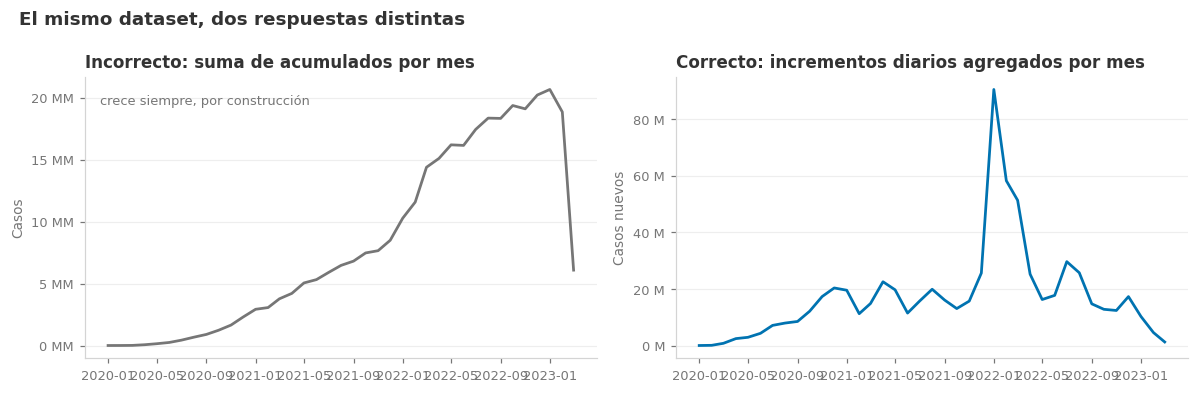

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].plot(incorrecto.index.to_timestamp(), incorrecto.values, color=GRIS_OSC, lw=1.8)
ax[0].set_title("Incorrecto: suma de acumulados por mes")
ax[0].set_ylabel("Casos")
ax[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1e9:,.0f} MM"))
ax[0].text(0.03, 0.9, "crece siempre, por construcción", transform=ax[0].transAxes,
           fontsize=8.5, color=GRIS_OSC)

ax[1].plot(mensual.index.to_timestamp(), mensual.values, color=AZUL, lw=1.8)
ax[1].set_title("Correcto: incrementos diarios agregados por mes")
ax[1].set_ylabel("Casos nuevos")
ax[1].yaxis.set_major_formatter(FuncFormatter(millones))

for a in ax:
    a.grid(axis="y")
    a.set_axisbelow(True)

fig.suptitle("El mismo dataset, dos respuestas distintas", x=0.02, ha="left",
             fontsize=12, fontweight="bold", color=TEXTO)
fig.tight_layout()
plt.show()

La diferencia no es de matiz. El procedimiento incorrecto ubica el máximo en el último mes del
registro; el correcto lo ubica en enero de 2022, y ese sí corresponde a un hecho epidemiológico
documentado: la ola de Ómicron.

## 4. Calidad del dato

Antes de interpretar conviene declarar en qué estado llega el archivo.

In [7]:
calidad = pd.DataFrame({
    "Indicador": [
        "Filas (unidades territoriales)",
        "Columnas de fecha",
        "Celdas de conteo",
        "Faltantes en los conteos",
        "Faltantes en Province/State",
        "Filas duplicadas",
        "Series acumuladas no monótonas",
        "Incrementos diarios negativos",
    ],
    "Valor": [
        f"{crudo.shape[0]}",
        f"{len(columnas_fecha)}",
        f"{crudo[columnas_fecha].size:,}",
        f"{int(crudo[columnas_fecha].isna().sum().sum())}",
        f"{int(crudo['Province/State'].isna().sum())} "
        f"({100*crudo['Province/State'].isna().mean():.1f} %)",
        f"{int(crudo.duplicated().sum())}",
        f"{retrocesos}",
        f"{negativos} ({100*negativos/validos:.3f} %)",
    ],
})
calidad

,Indicador,Valor
0,Filas (unidades territoriales),289
1,Columnas de fecha,1143
2,Celdas de conteo,"330,327"
3,Faltantes en los conteos,0
4,Faltantes en Province/State,198 (68.5 %)
5,Filas duplicadas,0
6,Series acumuladas no monótonas,128
7,Incrementos diarios negativos,171 (0.074 %)


El archivo no tiene faltantes ni duplicados. `Province/State` está vacío en la mayoría de filas,
pero eso es estructura, no ausencia: solo unos pocos países desagregan por provincia. El único
defecto real son las series que retroceden en algún punto, y son correcciones retroactivas de los
propios reportantes, no ruido aleatorio.

## 5. Distribución de la serie diaria mundial

La serie de casos nuevos por día es fuertemente asimétrica: unos pocos días concentran una
fracción desproporcionada del total. Los estadísticos lo confirman, y con esa asimetría la media
deja de ser un resumen informativo.

In [8]:
diaria = pais.groupby("Fecha")["Nuevos"].sum().iloc[1:]   # se descarta el primer día (sin diff)

desc = pd.Series({
    "Días": diaria.size,
    "Media": diaria.mean(),
    "Mediana": diaria.median(),
    "Desv. estándar": diaria.std(),
    "Mínimo": diaria.min(),
    "Q1": diaria.quantile(.25),
    "Q3": diaria.quantile(.75),
    "Máximo": diaria.max(),
    "Asimetría": stats.skew(diaria),
    "Curtosis (exceso)": stats.kurtosis(diaria),
})
print(desc.apply(lambda v: f"{v:,.2f}").to_string())

sw = stats.shapiro(diaria)
print(f"\nShapiro-Wilk: W = {sw.statistic:.4f}, p = {sw.pvalue:.3e}")
print("Se rechaza la normalidad: la serie diaria no es normal, "
      "como corresponde a un proceso con brotes.")
print(f"\nDía pico: {diaria.idxmax():%d/%m/%Y} con {diaria.max():,.0f} casos")
print(f"El 10 % de días con más casos concentra "
      f"{100*diaria.nlargest(int(.1*diaria.size)).sum()/diaria.sum():.1f} % del total")

Días                     1,142.00
Media                  593,188.20
Mediana                476,804.00
Desv. estándar         595,608.27
Mínimo                     100.00
Q1                     265,246.25
Q3                     678,054.75
Máximo               4,083,281.00
Asimetría                    2.84
Curtosis (exceso)           10.01

Shapiro-Wilk: W = 0.7073, p = 1.267e-40
Se rechaza la normalidad: la serie diaria no es normal, como corresponde a un proceso con brotes.

Día pico: 19/01/2022 con 4,083,281 casos
El 10 % de días con más casos concentra 34.6 % del total


## 6. El mes que nadie esperaba: enero de 2022

Con la serie ya diferenciada, la respuesta a la primera pregunta cambia por completo.

In [9]:
top_meses = mensual.sort_values(ascending=False).head(5)

tabla_meses = pd.DataFrame({
    "Mes": [str(m) for m in top_meses.index],
    "Casos nuevos": top_meses.values,
    "% del total mundial": 100 * top_meses.values / mundial_total,
})
tabla_meses["Casos nuevos"] = tabla_meses["Casos nuevos"].map("{:,.0f}".format)
tabla_meses["% del total mundial"] = tabla_meses["% del total mundial"].map("{:.1f} %".format)
tabla_meses

,Mes,Casos nuevos,% del total mundial
0,2022-01,"90,511,973",13.4 %
1,2022-02,"58,260,095",8.6 %
2,2022-03,"51,347,389",7.6 %
3,2022-07,"29,654,175",4.4 %
4,2022-08,"25,725,958",3.8 %


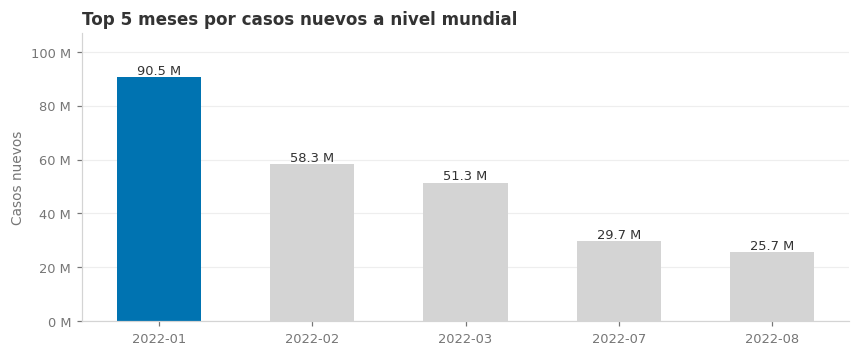

Enero de 2022 concentra el 13.4 % de todo el acumulado de tres años, en 31 días.
Los cuatro meses siguientes del ranking también son de 2022.


In [10]:
fig, ax = plt.subplots(figsize=(9, 3.4))

etiquetas = [str(m) for m in top_meses.index]
colores = [AZUL] + [GRIS] * 4
barras = ax.bar(etiquetas, top_meses.values, color=colores, width=.55)

for b, v in zip(barras, top_meses.values):
    ax.text(b.get_x() + b.get_width()/2, v + 1.2e6, f"{v/1e6:,.1f} M",
            ha="center", fontsize=8.5, color=TEXTO)

ax.set_title("Top 5 meses por casos nuevos a nivel mundial")
ax.set_ylabel("Casos nuevos")
ax.yaxis.set_major_formatter(FuncFormatter(millones))
ax.set_ylim(0, top_meses.max() * 1.18)
ax.grid(axis="y"); ax.set_axisbelow(True)
plt.show()

print(f"Enero de 2022 concentra el {100*top_meses.iloc[0]/mundial_total:.1f} % "
      f"de todo el acumulado de tres años, en 31 días.")
print("Los cuatro meses siguientes del ranking también son de 2022.")

La pandemia no fue una ola sino una serie de escalones, y el más alto está muy cerca del final
del registro. Cualquier lectura que asuma que 2020 fue el año crítico contradice el dato.

### 6.1 Quién aportó ese mes

In [11]:
mes_pico = mensual.idxmax()
enero22 = (pais[pais["Mes"] == mes_pico]
           .groupby("Country/Region")["Nuevos"].sum()
           .sort_values(ascending=False))

tabla_paises = pd.DataFrame({
    "País": enero22.head(5).index,
    "Casos nuevos": enero22.head(5).values,
    "% del mes": 100 * enero22.head(5).values / enero22.sum(),
})
tabla_paises["Casos nuevos"] = tabla_paises["Casos nuevos"].map("{:,.0f}".format)
tabla_paises["% del mes"] = tabla_paises["% del mes"].map("{:.1f} %".format)

print(f"Mes pico: {mes_pico}")
tabla_paises

Mes pico: 2022-01


,País,Casos nuevos,% del mes
0,US,"20,336,435",22.5 %
1,France,"9,188,713",10.2 %
2,India,"6,607,920",7.3 %
3,Italy,"4,857,433",5.4 %
4,United Kingdom,"4,420,003",4.9 %


## 7. Tres países, tres historias distintas

El total mensual global esconde una heterogeneidad que ninguna tabla de totales deja ver. Tres
países con volúmenes comparables siguieron trayectorias temporales muy diferentes, y esa
diferencia solo se percibe gráficamente.

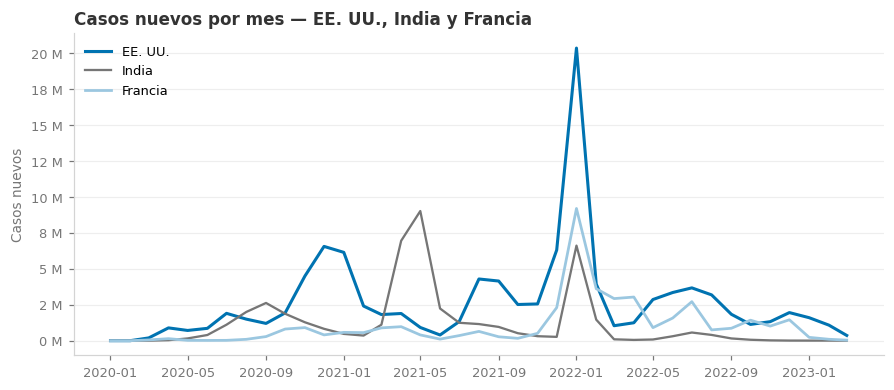

In [12]:
seleccion = ["US", "India", "France"]
nombres = {"US": "EE. UU.", "India": "India", "France": "Francia"}

serie_pais = (pais[pais["Country/Region"].isin(seleccion)]
              .groupby(["Country/Region", "Mes"])["Nuevos"].sum()
              .unstack(0))

fig, ax = plt.subplots(figsize=(9.5, 3.8))
estilos = {"US": (AZUL, 2.0), "India": (GRIS_OSC, 1.5), "France": ("#9BC7E0", 1.8)}

for c in seleccion:
    color, lw = estilos[c]
    ax.plot(serie_pais.index.to_timestamp(), serie_pais[c], label=nombres[c],
            color=color, lw=lw)

ax.set_title("Casos nuevos por mes — EE. UU., India y Francia")
ax.set_ylabel("Casos nuevos")
ax.yaxis.set_major_formatter(FuncFormatter(millones))
ax.legend(loc="upper left")
ax.grid(axis="y"); ax.set_axisbelow(True)
plt.show()

In [13]:
# Caracterización cuantitativa de cada trayectoria
resumen = []
for c in seleccion:
    s = serie_pais[c].dropna()
    resumen.append({
        "País": nombres[c],
        "Mes pico": str(s.idxmax()),
        "Casos en el pico": f"{s.max():,.0f}",
        "% del total del país en el pico": f"{100*s.max()/s.sum():.1f} %",
        "Meses para el 50 % del total": int((s.sort_values(ascending=False)
                                             .cumsum() <= .5*s.sum()).sum() + 1),
        "Coef. de variación": f"{s.std()/s.mean():.2f}",
    })
pd.DataFrame(resumen)

,País,Mes pico,Casos en el pico,% del total del país en el pico,Meses para el 50 % del total,Coef. de variación
0,EE. UU.,2022-01,"20,336,435",19.6 %,7,1.26
1,India,2021-05,"9,010,075",20.2 %,3,1.75
2,Francia,2022-01,"9,188,713",22.8 %,5,1.58


La lectura es directa: EE. UU. sostuvo carga durante casi todo el período y aun así concentró un
pico marcado en enero de 2022 con Ómicron. India tuvo un pico agudo y breve en mayo de 2021 con
la variante Delta, con un coeficiente de variación mayor —su serie es la más desigual de las
tres— y una caída igualmente rápida. Francia acumuló repuntes sucesivos, coherentes con las
oleadas europeas. Tres patrones epidemiológicos distintos que un total agregado convierte en un
solo número.

## 8. La asimetría global: cinco países, 39 % de la pandemia

La concentración entre países se puede afirmar con una cifra, pero conviene medirla. La curva de
Lorenz y el coeficiente de Gini cuantifican qué tan desigual es el reparto de casos acumulados
entre los 201 territorios del registro.

In [14]:
acum_pais = (pais.groupby("Country/Region")["Acumulados"].max()
                 .sort_values(ascending=False))

top5 = acum_pais.head(5)
print("Top 5 países por casos acumulados:")
for p, v in top5.items():
    print(f"  {p:<10} {v:>12,}   {100*v/mundial_total:>5.1f} %")
print(f"\nLos cinco concentran el {100*top5.sum()/mundial_total:.2f} % del total mundial.")
print(f"El {100 - 100*top5.sum()/mundial_total:.2f} % restante se reparte entre "
      f"{acum_pais.size - 5} países y territorios.")

def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = x.size
    return (2*np.sum((np.arange(1, n+1)) * x) - (n + 1) * x.sum()) / (n * x.sum())

g = gini(acum_pais.values)
print(f"\nCoeficiente de Gini de casos acumulados entre países: {g:.3f}")

Top 5 países por casos acumulados:
  US          103,802,702    15.3 %
  India        44,690,738     6.6 %
  France       39,866,718     5.9 %
  Germany      38,249,060     5.7 %
  Brazil       37,081,209     5.5 %

Los cinco concentran el 38.97 % del total mundial.
El 61.03 % restante se reparte entre 196 países y territorios.

Coeficiente de Gini de casos acumulados entre países: 0.841


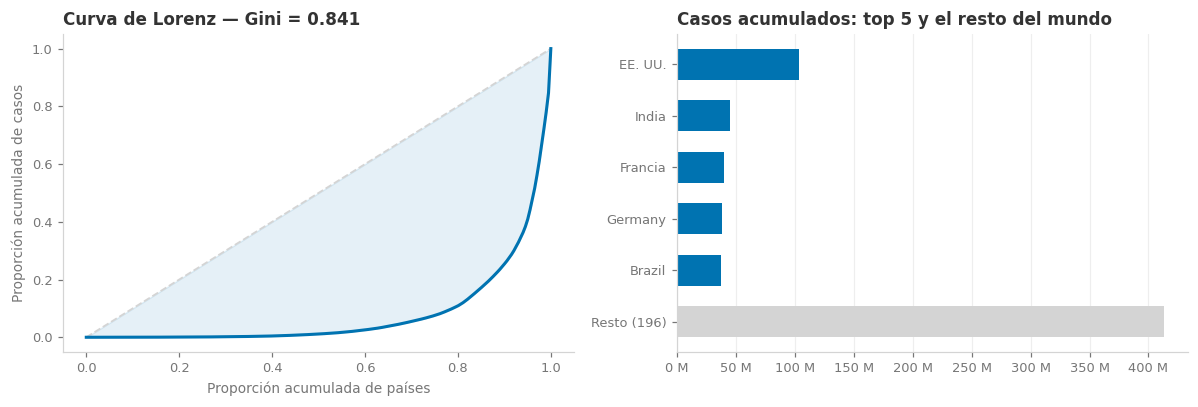

In [15]:
x = np.sort(acum_pais.values)
p_acum = np.insert(np.cumsum(x) / x.sum(), 0, 0)
p_pais = np.linspace(0, 1, x.size + 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

# Lorenz
ax[0].plot([0, 1], [0, 1], color=GRIS, lw=1.2, ls="--")
ax[0].plot(p_pais, p_acum, color=AZUL, lw=2)
ax[0].fill_between(p_pais, p_acum, p_pais, color=AZUL, alpha=.10)
ax[0].set_title(f"Curva de Lorenz — Gini = {g:.3f}")
ax[0].set_xlabel("Proporción acumulada de países")
ax[0].set_ylabel("Proporción acumulada de casos")

# Top 5 vs resto
etiquetas = [nombres.get(p, p) for p in top5.index] + ["Resto (196)"]
valores = list(top5.values) + [mundial_total - top5.sum()]
colores = [AZUL]*5 + [GRIS]
ax[1].barh(etiquetas[::-1], valores[::-1], color=colores[::-1], height=.6)
ax[1].set_title("Casos acumulados: top 5 y el resto del mundo")
ax[1].xaxis.set_major_formatter(FuncFormatter(millones))
ax[1].grid(axis="x"); ax[1].set_axisbelow(True)

fig.tight_layout()
plt.show()

El Gini es alto, pero el dato que importa no es el del top 5 sino su complemento: más de 190
países se reparten el 61 % restante. La pandemia fue efectivamente planetaria, y un análisis
limitado a los cinco primeros deja fuera más de la mitad de la historia.

## 9. La trampa del dato reportado: Corea del Norte

La última pregunta parece la más simple y es la más delicada. El país con menos casos en el
registro tiene exactamente un caso acumulado. Ese número es correcto como dato y falso como
descripción del fenómeno.

In [16]:
menores = acum_pais.tail(5).sort_values()
pd.DataFrame({
    "Territorio": menores.index,
    "Casos acumulados": menores.values,
})

,Territorio,Casos acumulados
0,"Korea, North",1
1,MS Zaandam,9
2,Antarctica,11
3,Holy See,29
4,Winter Olympics 2022,535


Corea del Norte reporta un caso acumulado en todo el período. Las propias autoridades
norcoreanas reconocieron internamente cerca de 4,77 millones de personas con síntomas febriles
entre abril y agosto de 2022. El uno no describe su epidemiología: describe su política de
comunicación.

Las otras entradas de la cola tampoco son países en sentido estricto —un crucero, la Antártida—,
lo que recuerda que la unidad de análisis del archivo no es homogénea.

La consecuencia metodológica es general y vale para cualquier trabajo con fuentes secundarias:
la pregunta contestable no es *¿cuántos casos tuvo?* sino *¿cuántos reportó al repositorio?*. Son
preguntas distintas, con respuestas distintas, y confundirlas convierte una limitación de la
fuente en una afirmación sobre el mundo.

## 10. Conclusiones

**Sobre el método.** El mayor desafío del dataset no fue su tamaño sino su estructura. La
distinción entre conteos acumulados y conteos diarios cambia por completo la respuesta a una
pregunta aparentemente trivial: el procedimiento ingenuo ubica el máximo en el último mes del
registro, y el correcto lo ubica en enero de 2022. Ningún volumen de datos compensa un error de
tratamiento en el primer paso.

**Sobre los hallazgos.** El mes con más contagios nuevos fue enero de 2022, con más de 90,5
millones de casos: el 13,4 % de todo el acumulado de tres años concentrado en 31 días. En ese
mes, Estados Unidos aportó 20,3 millones, el 22,5 % del total mundial del período. Los cinco
países con más casos acumulados concentran el 38,97 % del total, con un coeficiente de Gini
entre países de 0,84; el resto se reparte entre más de 190 territorios.

**Sobre la calidad de la fuente.** La cobertura de un dataset no garantiza su fidelidad. El caso
de Corea del Norte muestra que la calidad no se mide solo por completitud sino por la honestidad
de quien reporta, y que esa dimensión no aparece en ningún indicador de faltantes.

---

### Fuentes

Dong, E., Du, H., y Gardner, L. (2020). *An interactive web-based dashboard to track COVID-19 in
real time*. The Lancet Infectious Diseases, 20(5), 533–534.

CSSEGISandData (2023). *COVID-19 Data Repository by the Center for Systems Science and
Engineering at Johns Hopkins University*. github.com/CSSEGISandData/COVID-19

Nussbaumer Knaflic, C. (2015). *Storytelling with Data: A Data Visualization Guide for Business
Professionals*. Wiley.

Luis Javier Rubio Hernández